In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error, mean_squared_error
import json

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Data Loading & Aggregation

dataset_path = '/kaggle/input/datasets/omarhusnye/electronicsnew/clean_events_electronics_computers.csv'

# Load the real dataset
df_raw = pd.read_csv(dataset_path)
df_raw.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,year,...,category_l1,category_l2,category_l3,is_pc_component,component_type,product_group,is_likely_bot_session,price_band,brand_is_unknown,category_l3_is_unknown
0,2020-09-24 11:57:06+00:00,view,1996170,2144415922528452715,electronics.telephone,unknown,31.90,1515915625519388267,LJuJVLEjPT,2020,...,electronics,telephone,unknown,False,not_a_component,Mobile & Telephony,False,$25-50,1,1
1,2020-09-24 11:57:26+00:00,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY,2020,...,computers,components,cooler,True,cooler,PC Components,False,<$25,0,0
2,2020-09-24 11:57:33+00:00,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,aGFYrNgC08,2020,...,computers,peripherals,printer,False,not_a_component,PC Peripherals,False,$100-250,0,0
3,2020-09-24 11:58:23+00:00,view,3791349,2144415935086199225,computers.desktop,unknown,215.41,1515915625519388877,J1t6sIYXiV,2020,...,computers,desktop,unknown,False,not_a_component,PC Systems,False,$100-250,1,1
4,2020-09-24 11:58:24+00:00,view,716611,2144415923694469257,computers.network.router,d-link,53.14,1515915625519388882,kVBeYDPcBw,2020,...,computers,network,router,False,not_a_component,PC Peripherals,False,$50-100,0,0


In [3]:
# Ensure event_time is a datetime object
df_raw['event_time'] = pd.to_datetime(df_raw['event_time'])

# OPTIMIZATION: Create fast integer columns for aggregation to prevent RAM crashes
df_raw['is_view'] = (df_raw['event_type'] == 'view').astype(int)
df_raw['is_cart'] = (df_raw['event_type'] == 'cart').astype(int)
df_raw['is_purchase'] = (df_raw['event_type'] == 'purchase').astype(int)

# Calculate revenue only for purchase events
df_raw['revenue_contribution'] = np.where(df_raw['event_type'] == 'purchase', df_raw['price'], 0.0)

# Group by date and product_id
df = df_raw.groupby([df_raw['event_time'].dt.date, 'product_id']).agg(
    views=('is_view', 'sum'),
    carts=('is_cart', 'sum'),
    purchases=('is_purchase', 'sum'),
    revenue=('revenue_contribution', 'sum')
).reset_index()

# Rename for consistency with the rest of the pipeline
df.rename(columns={'event_time': 'date'}, inplace=True)
df['date'] = pd.to_datetime(df['date'])

# Sort chronologically for each product
df.sort_values(['product_id', 'date'], inplace=True)
df.reset_index(drop=True, inplace=True)

del df_raw

print(f"Aggregated dataset shape: {df.shape}")
display(df.head())

Aggregated dataset shape: (198278, 6)


,date,product_id,views,carts,purchases,revenue
0,2020-09-29,854,1,0,0,0.00
1,2020-09-30,854,1,0,7,10.99
2,2020-10-31,1245,1,0,0,0.00
3,2020-11-16,1245,1,0,0,0.00
4,2020-11-21,1245,1,0,0,0.00


In [4]:
# Date/Time Features
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df['month'] = df['date'].dt.month

In [5]:
# Lag Features (What happened 1 day ago? 7 days ago?)
# We group by product_id so we don't bleed previous days of different products

lag_features = ['views', 'carts', 'purchases']
for col in lag_features:
    df[f'{col}_lag_1'] = df.groupby('product_id')[col].shift(1)
    df[f'{col}_lag_7'] = df.groupby('product_id')[col].shift(7)

In [6]:
# Rolling Window Statistics (7-day trend)
for col in lag_features:
    df[f'{col}_rolling_7d_mean'] = df.groupby('product_id')[col].transform(
        lambda x: x.shift(1).rolling(window=7).mean()
    )

# Drop rows with NaN values caused by shifting/rolling
df.dropna(inplace=True)

In [8]:
# Define our target variable (e.g., predicting tomorrow's purchases)
target = 'purchases'

# Define our features
features = [
    'day_of_week', 'is_weekend', 'month',
    'views_lag_1', 'carts_lag_1', 'purchases_lag_1',
    'views_lag_7', 'carts_lag_7', 'purchases_lag_7',
    'views_rolling_7d_mean', 'carts_rolling_7d_mean', 'purchases_rolling_7d_mean'
]

In [9]:
# Split the last 15 days for testing
split_date = df['date'].max() - pd.Timedelta(days=15)

train_df = df[df['date'] < split_date]
test_df = df[df['date'] >= split_date]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print(f"Training shapes: X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Testing shapes: X_test: {X_test.shape}, y_test: {y_test.shape}")

Training shapes: X_train: (99162, 12), y_train: (99162,)
Testing shapes: X_test: (15017, 12), y_test: (15017,)


In [10]:
# Initialize and train the Regressor
model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    eval_metric='MAE',
    random_seed=42,
    verbose=100
)

# Use Pool for efficient memory management
train_pool = Pool(X_train, y_train)
test_pool = Pool(X_test, y_test)

model.fit(train_pool, eval_set=test_pool, early_stopping_rounds=50)

0:	learn: 0.2945049	test: 0.3132942	best: 0.3132942 (0)	total: 69.9ms	remaining: 34.9s
100:	learn: 0.2338578	test: 0.2477836	best: 0.2477836 (100)	total: 650ms	remaining: 2.57s
200:	learn: 0.2306377	test: 0.2460234	best: 0.2459642 (193)	total: 1.21s	remaining: 1.8s
300:	learn: 0.2285184	test: 0.2455178	best: 0.2454524 (294)	total: 1.77s	remaining: 1.17s
400:	learn: 0.2269643	test: 0.2447050	best: 0.2446991 (395)	total: 2.32s	remaining: 573ms
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.2446342842
bestIteration = 406

Shrink model to first 407 iterations.


CatBoostRegressor(depth=6, eval_metric='MAE', iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=100)

In [12]:
# Evaluate predictions
preds = model.predict(X_test)
# Ensure no negative predictions (you can't sell negative units)
preds = np.maximum(0, preds) 

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print("\n--- Model Performance ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} units")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} units")


--- Model Performance ---
Mean Absolute Error (MAE): 0.24 units
Root Mean Squared Error (RMSE): 0.64 units


In [14]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    objective='reg:squarederror',
    random_state=42,
    early_stopping_rounds=50
)

In [15]:
# Train the model
# XGBoost requires the eval_set to be passed as a list of tuples
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

[0]	validation_0-rmse:0.76331
[91]	validation_0-rmse:0.63510


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [16]:
# Evaluate predictions
preds_xgb = xgb_model.predict(X_test)

# Ensure no negative predictions (you can't sell negative units)
preds_xgb = np.maximum(0, preds_xgb) 

# Calculate Metrics
mae_xgb = mean_absolute_error(y_test, preds_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, preds_xgb))

print("\n--- XGBoost Model Performance ---")
print(f"Mean Absolute Error (MAE): {mae_xgb:.2f} units")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.2f} units")


--- XGBoost Model Performance ---
Mean Absolute Error (MAE): 0.25 units
Root Mean Squared Error (RMSE): 0.63 units


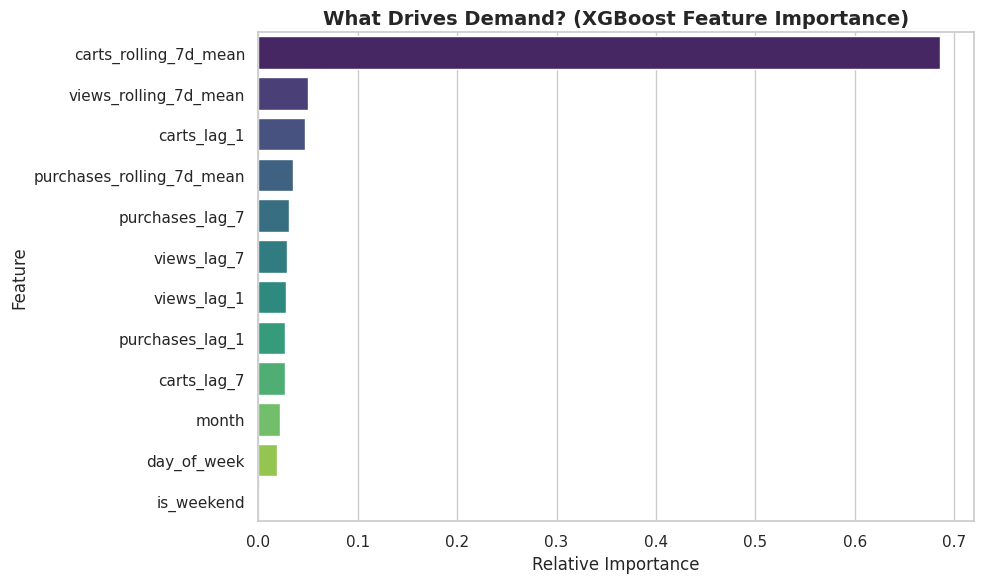

In [18]:
# Feature Importance Bar Chart

importances = xgb_model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': FEATURES, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('What Drives Demand? (XGBoost Feature Importance)', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [19]:
# Actual vs. Predicted (Time Series Overlay)
# To make the chart readable, let's pick a single top-selling product
# First, find the product with the most sales in the test set
top_product = test_df.groupby('product_id')[TARGET].sum().idxmax()

In [20]:
# Filter the test set and predictions for just this product
product_mask = test_df['product_id'] == top_product
dates_plot = test_df.loc[product_mask, 'date']
actual_sales = y_test[product_mask]
predicted_sales = preds_xgb[product_mask]

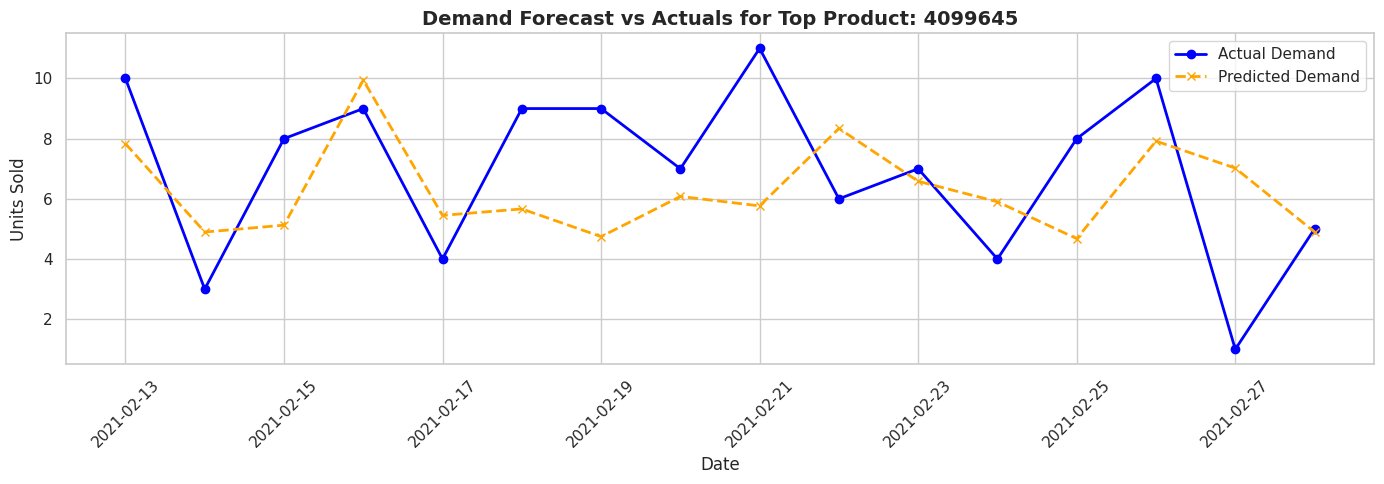

In [21]:
plt.figure(figsize=(14, 5))
plt.plot(dates_plot, actual_sales, label='Actual Demand', color='blue', marker='o', linewidth=2)
plt.plot(dates_plot, predicted_sales, label='Predicted Demand', color='orange', linestyle='--', marker='x', linewidth=2)

plt.title(f'Demand Forecast vs Actuals for Top Product: {top_product}', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
print("--- Running Viral Spike Simulation ---")

# Pick the top-selling product in the test set instead of a random zero-sales item
top_products = test_df.groupby('product_id')[target].sum()
active_product = top_products[top_products > 0].index[0]

baseline_data = test_df[test_df['product_id'] == active_product].copy()

# Select the midpoint date as our viral event
viral_index = baseline_data.index[len(baseline_data) // 2]
viral_date = baseline_data.loc[viral_index, 'date']

# Inject a 10x spike into views and 5x into carts for that date
baseline_data.loc[viral_index, 'views_lag_1'] *= 10  
baseline_data.loc[viral_index, 'carts_lag_1'] *= 5   

# Re-run prediction on the active product data
simulated_X = baseline_data[features]
simulated_preds = xgb_model.predict(simulated_X)
simulated_preds = np.maximum(0, simulated_preds)

--- Running Viral Spike Simulation ---


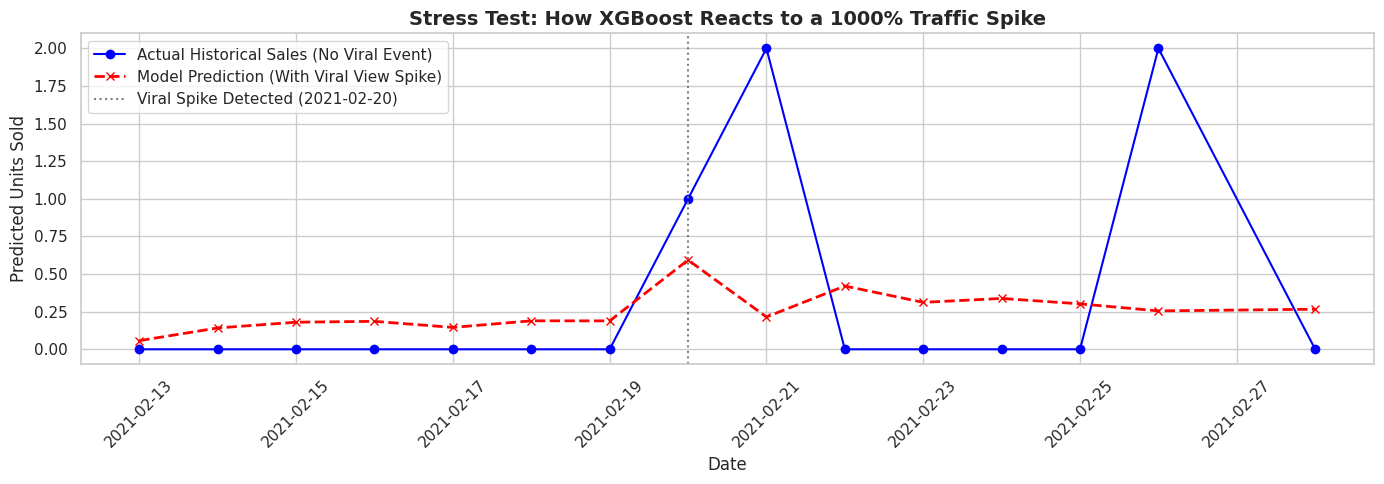

In [30]:
plt.figure(figsize=(14, 5))

# Plot the original actual sales
plt.plot(baseline_data['date'], baseline_data[target], 
         label='Actual Historical Sales (No Viral Event)', color='blue', marker='o')

# Plot the model's prediction WITH the viral spike injected
plt.plot(baseline_data['date'], simulated_preds, 
         label='Model Prediction (With Viral View Spike)', color='red', linestyle='--', marker='x', linewidth=2)

# Highlight the viral day
plt.axvline(x=viral_date, color='grey', linestyle=':', label=f'Viral Spike Detected ({viral_date.date()})')

plt.title(f'Stress Test: How XGBoost Reacts to a 1000% Traffic Spike', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Predicted Units Sold')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('What Drives Demand? (XGBoost Feature Importance)', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()

plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.close() 
print("feature_importance.png")

feature_importance.png


In [32]:
plt.figure(figsize=(14, 5))
plt.plot(baseline_data['date'], baseline_data[TARGET], label='Actual Historical Sales', color='blue', marker='o')
plt.plot(baseline_data['date'], simulated_preds, label='Model Prediction', color='red', linestyle='--', marker='x', linewidth=2)
plt.axvline(x=viral_date, color='grey', linestyle=':')
plt.title(f'Stress Test: How XGBoost Reacts to a 1000% Traffic Spike', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Predicted Units Sold')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('viral_spike_simulation.png', dpi=300, bbox_inches='tight')
plt.close()
print("viral_spike_simulation.png")

viral_spike_simulation.png


In [34]:
xgb_model.save_model('demand_forecast_xgboost.json')
print("demand_forecast_xgboost.json")

metadata_xgb = {
    "model_type": "XGBRegressor",
    "task": "Product Demand Forecasting",
    "target_variable": target,
    "expected_features": features,
    "handling_rules": {
        "cold_start_days": 14,
        "anomaly_multiplier": "Override model if views > 500% of 7-day average"
    },
    "feature_importance": dict(zip(features, xgb_model.feature_importances_.tolist()))
}


with open('metadata.json', 'w') as f:
    json.dump(metadata_xgb, f, indent=4)
print("metadata.json")


train_df.to_csv('train_data_processed.csv', index=False)
test_df.to_csv('test_data_processed.csv', index=False)

print("train_data_processed.csv")
print("test_data_processed.csv")

demand_forecast_xgboost.json
metadata.json
train_data_processed.csv
test_data_processed.csv
